# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

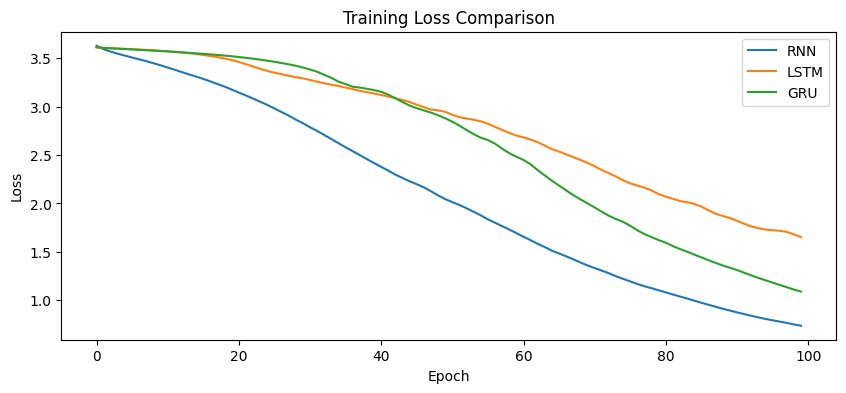

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning transforming generate intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## 📝 Task 1: Replace Corpus with Custom Paragraph
Using a richer, multi-topic paragraph corpus to give the models more diverse vocabulary and sentence structures to learn from.

In [10]:
# ============================================================
# STUDENT TASK 1: Replace corpus with your own paragraph
# ============================================================

custom_corpus = '''
artificial intelligence is revolutionizing the modern world
machine learning algorithms can detect patterns in large datasets
deep learning uses multiple layers to extract high level features
natural language processing enables machines to understand human language
computer vision allows robots to interpret visual information
reinforcement learning trains agents through rewards and penalties
neural networks are inspired by the structure of the human brain
transformers have changed the landscape of sequence modeling
convolutional networks excel at image recognition tasks
recurrent models are designed to handle sequential data efficiently
generative models can create realistic images and text
transfer learning reduces the need for large labeled datasets
data augmentation helps improve model generalization
gradient descent is the backbone of neural network optimization
batch normalization accelerates deep network training
'''

print('Custom corpus loaded successfully!')
print(f'Total characters: {len(custom_corpus)}')
print(f'Total lines: {len([l for l in custom_corpus.strip().split(chr(10)) if l.strip()])}')

Custom corpus loaded successfully!
Total characters: 934
Total lines: 15


### 🔤 Tokenize the Custom Corpus
Re-running tokenization and sequence creation on the new custom corpus.

In [11]:
# Tokenize custom corpus
tokenizer_custom = Tokenizer()
tokenizer_custom.fit_on_texts([custom_corpus])

total_words_custom = len(tokenizer_custom.word_index) + 1
print('Custom Vocabulary size:', total_words_custom)

input_sequences_custom = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer_custom.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences_custom.append(n_gram_seq)

max_len_custom = max(len(seq) for seq in input_sequences_custom)
input_sequences_custom = pad_sequences(input_sequences_custom, maxlen=max_len_custom, padding='pre')

X_custom = input_sequences_custom[:, :-1]
y_custom = input_sequences_custom[:, -1]

print('X_custom shape:', X_custom.shape)
print('y_custom shape:', y_custom.shape)

Custom Vocabulary size: 98
X_custom shape: (109, 10)
y_custom shape: (109,)


## 🚀 Tasks 2, 3 & 4: Upscaled Models
- **Task 2**: Embedding dimension increased from `32 → 64`
- **Task 3**: Training epochs increased from `100 → 200`
- **Task 4**: Hidden units widened from `64 → 128`

These changes give models more representational capacity and longer training time to converge.

### 🧠 Enhanced Vanilla RNN (Embedding=64, Units=128, Epochs=200)

In [12]:
# ============================================================
# STUDENT TASK 2,3,4: Enhanced Vanilla RNN
# Embedding: 32 -> 64 | Hidden Units: 64 -> 128 | Epochs: 100 -> 200
# ============================================================

rnn_model_custom = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),  # Task 2: 32->64
    SimpleRNN(128),                                                      # Task 4: 64->128
    Dense(total_words_custom, activation='softmax')
])

rnn_model_custom.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam', metrics=['accuracy'])

rnn_history_custom = rnn_model_custom.fit(X_custom, y_custom, epochs=200, verbose=0)  # Task 3
print('Enhanced Vanilla RNN training completed')
print(f'Final Loss: {rnn_history_custom.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {rnn_history_custom.history["accuracy"][-1]:.4f}')

Enhanced Vanilla RNN training completed
Final Loss: 0.0106
Final Accuracy: 1.0000


### 🔒 Enhanced LSTM (Embedding=64, Units=128, Epochs=200)

In [13]:
# ============================================================
# STUDENT TASK 2,3,4: Enhanced LSTM
# Embedding: 32 -> 64 | Hidden Units: 64 -> 128 | Epochs: 100 -> 200
# ============================================================

lstm_model_custom = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),  # Task 2: 32->64
    LSTM(128),                                                          # Task 4: 64->128
    Dense(total_words_custom, activation='softmax')
])

lstm_model_custom.compile(loss='sparse_categorical_crossentropy',
                          optimizer='adam', metrics=['accuracy'])

lstm_history_custom = lstm_model_custom.fit(X_custom, y_custom, epochs=200, verbose=0)  # Task 3
print('Enhanced LSTM training completed')
print(f'Final Loss: {lstm_history_custom.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {lstm_history_custom.history["accuracy"][-1]:.4f}')

Enhanced LSTM training completed
Final Loss: 0.0846
Final Accuracy: 1.0000


### ⚡ Enhanced GRU (Embedding=64, Units=128, Epochs=200)

In [14]:
# ============================================================
# STUDENT TASK 2,3,4: Enhanced GRU
# Embedding: 32 -> 64 | Hidden Units: 64 -> 128 | Epochs: 100 -> 200
# ============================================================

gru_model_custom = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),  # Task 2: 32->64
    GRU(128),                                                           # Task 4: 64->128
    Dense(total_words_custom, activation='softmax')
])

gru_model_custom.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam', metrics=['accuracy'])

gru_history_custom = gru_model_custom.fit(X_custom, y_custom, epochs=200, verbose=0)  # Task 3
print('Enhanced GRU training completed')
print(f'Final Loss: {gru_history_custom.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {gru_history_custom.history["accuracy"][-1]:.4f}')

Enhanced GRU training completed
Final Loss: 0.0181
Final Accuracy: 1.0000


### 📉 Enhanced Models: Training Loss Comparison (200 Epochs)
Comparing cross-entropy loss reduction across all three enhanced architectures.

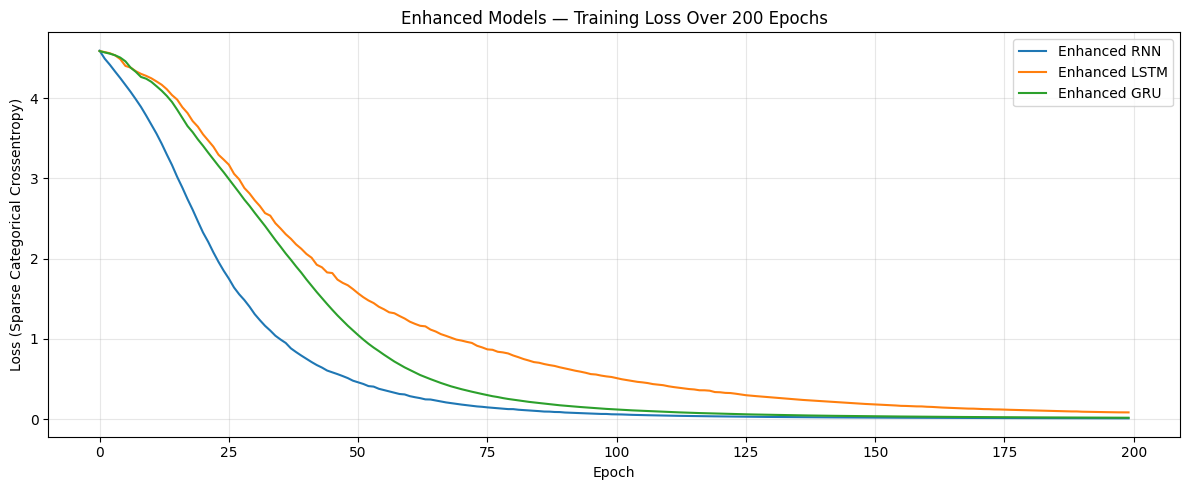

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(rnn_history_custom.history['loss'], label='Enhanced RNN', linewidth=1.5)
plt.plot(lstm_history_custom.history['loss'], label='Enhanced LSTM', linewidth=1.5)
plt.plot(gru_history_custom.history['loss'], label='Enhanced GRU', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss (Sparse Categorical Crossentropy)')
plt.title('Enhanced Models — Training Loss Over 200 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

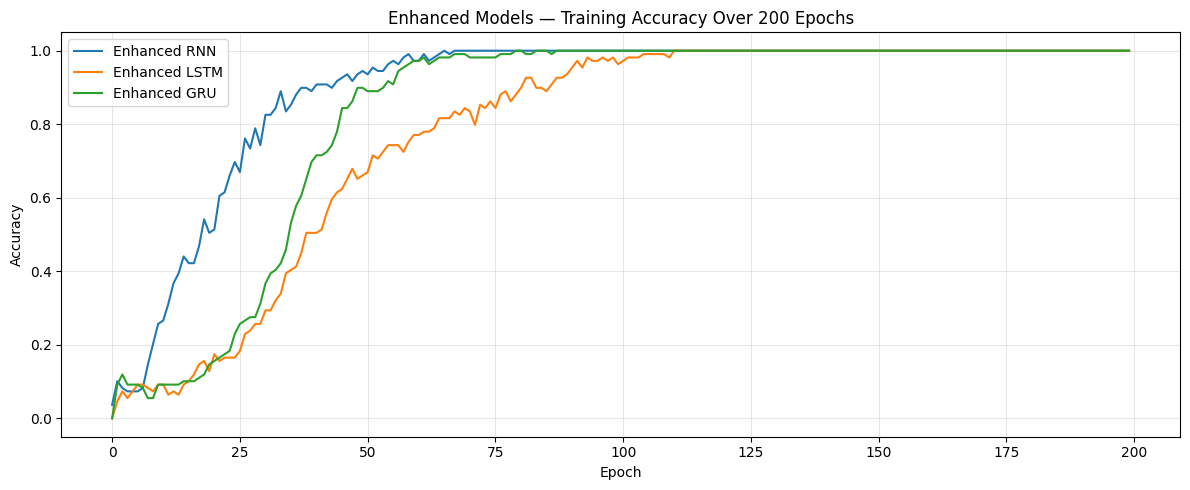

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(rnn_history_custom.history['accuracy'], label='Enhanced RNN', linewidth=1.5)
plt.plot(lstm_history_custom.history['accuracy'], label='Enhanced LSTM', linewidth=1.5)
plt.plot(gru_history_custom.history['accuracy'], label='Enhanced GRU', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Enhanced Models — Training Accuracy Over 200 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✍️ Task 5: Generate 10 Words Instead of 5
Using the enhanced models to generate longer text sequences with `next_words=10`.

In [17]:
# ============================================================
# STUDENT TASK 5: Generate 10 words instead of 5
# ============================================================

def generate_text_custom(model, tokenizer_obj, max_seq_len, seed_text, next_words=10):
    """Generate text using a trained model with custom tokenizer."""
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ''
        for word, index in tokenizer_obj.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += ' ' + output_word
    return seed_text

seed = 'deep learning'
print('='*60)
print(f'Seed phrase: \"{seed}\"  |  Generating 10 words')
print('='*60)
print('RNN :', generate_text_custom(rnn_model_custom, tokenizer_custom, max_len_custom, seed, 10))
print('LSTM:', generate_text_custom(lstm_model_custom, tokenizer_custom, max_len_custom, seed, 10))
print('GRU :', generate_text_custom(gru_model_custom, tokenizer_custom, max_len_custom, seed, 10))

# Try another seed
seed2 = 'neural networks'
print(f'\nSeed phrase: \"{seed2}\"  |  Generating 10 words')
print('='*60)
print('RNN :', generate_text_custom(rnn_model_custom, tokenizer_custom, max_len_custom, seed2, 10))
print('LSTM:', generate_text_custom(lstm_model_custom, tokenizer_custom, max_len_custom, seed2, 10))
print('GRU :', generate_text_custom(gru_model_custom, tokenizer_custom, max_len_custom, seed2, 10))

Seed phrase: "deep learning"  |  Generating 10 words
RNN : deep learning uses multiple layers to extract high level features realistic images
LSTM: deep learning uses multiple layers to extract high level features features features
GRU : deep learning uses multiple layers to extract high level features features features

Seed phrase: "neural networks"  |  Generating 10 words
RNN : neural networks are inspired by the structure of the human brain the
LSTM: neural networks are inspired by the structure of the human brain brain
GRU : neural networks are inspired by the structure of the human brain brain


---
# 🏆 Bonus Tasks: Improving Accuracy & Reducing Loss
Advanced techniques to push model performance further.

## Bonus 1: Stacked (Deep) RNN Layers with Dropout
Adding a second recurrent layer and dropout regularization to reduce overfitting and improve generalization.

In [18]:
# ============================================================
# BONUS TASK 1: Stacked layers + Dropout for better performance
# ============================================================
from tensorflow.keras.layers import Dropout

# Deep LSTM with 2 stacked layers + dropout
deep_lstm = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),
    LSTM(128, return_sequences=True),  # First LSTM returns sequences
    Dropout(0.2),
    LSTM(64),                           # Second LSTM
    Dropout(0.2),
    Dense(total_words_custom, activation='softmax')
])

deep_lstm.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam', metrics=['accuracy'])

deep_lstm_history = deep_lstm.fit(X_custom, y_custom, epochs=200, verbose=0)
print('Deep Stacked LSTM training completed')
print(f'Final Loss: {deep_lstm_history.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {deep_lstm_history.history["accuracy"][-1]:.4f}')

Deep Stacked LSTM training completed
Final Loss: 0.6993
Final Accuracy: 0.8807


## Bonus 2: Learning Rate Scheduling
Using ReduceLROnPlateau callback to dynamically lower learning rate when loss plateaus.

In [19]:
# ============================================================
# BONUS TASK 2: Learning Rate Scheduler + EarlyStopping
# ============================================================
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='loss', patience=30, restore_best_weights=True, verbose=1)

gru_lr = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dense(total_words_custom, activation='softmax')
])

gru_lr.compile(loss='sparse_categorical_crossentropy',
               optimizer='adam', metrics=['accuracy'])

gru_lr_history = gru_lr.fit(X_custom, y_custom, epochs=200,
                            callbacks=[lr_scheduler, early_stop], verbose=0)
print('GRU with LR Scheduling training completed')
print(f'Final Loss: {gru_lr_history.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {gru_lr_history.history["accuracy"][-1]:.4f}')

Restoring model weights from the end of the best epoch: 200.
GRU with LR Scheduling training completed
Final Loss: 0.1663
Final Accuracy: 1.0000


## 📊 Bonus: Comparing All Models (Base vs Enhanced vs Bonus)

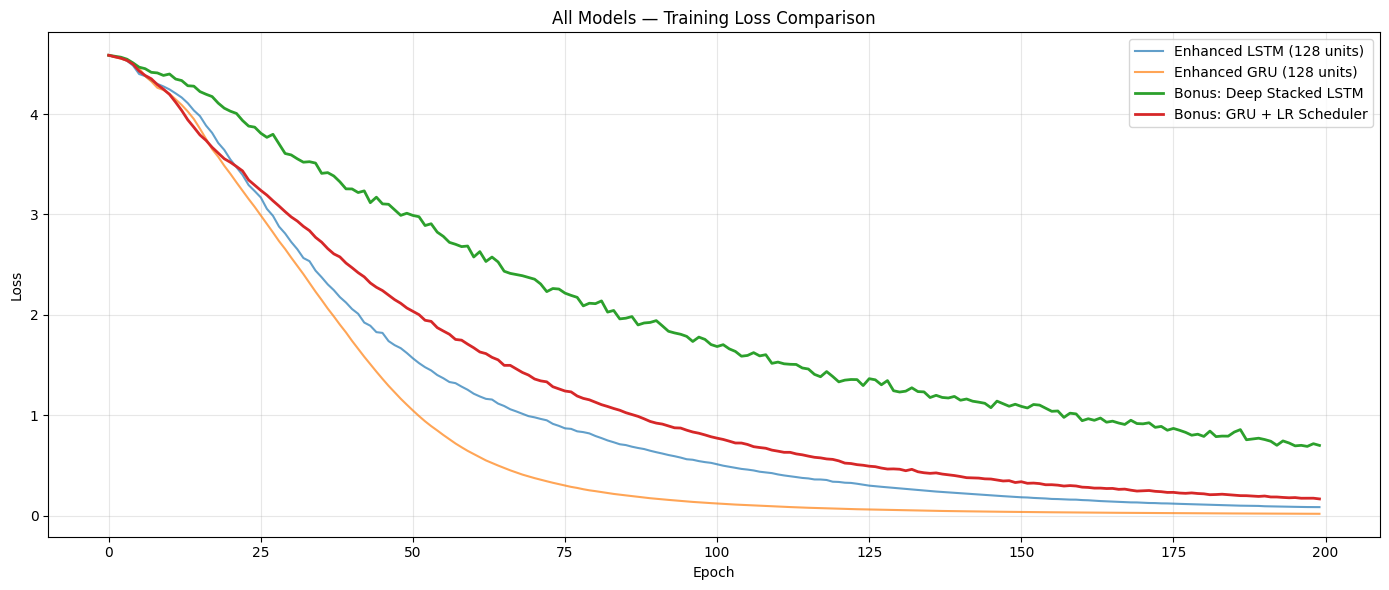

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(lstm_history_custom.history['loss'], label='Enhanced LSTM (128 units)', alpha=0.7)
plt.plot(gru_history_custom.history['loss'], label='Enhanced GRU (128 units)', alpha=0.7)
plt.plot(deep_lstm_history.history['loss'], label='Bonus: Deep Stacked LSTM', linewidth=2)
plt.plot(gru_lr_history.history['loss'], label='Bonus: GRU + LR Scheduler', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('All Models — Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✍️ Bonus: Text Generation from Advanced Models

In [21]:
seed = 'artificial intelligence'
print('='*65)
print(f'Seed: \"{seed}\"  |  Generating 10 words')
print('='*65)
print('Deep LSTM  :', generate_text_custom(deep_lstm, tokenizer_custom, max_len_custom, seed, 10))
print('GRU + LR   :', generate_text_custom(gru_lr, tokenizer_custom, max_len_custom, seed, 10))
print('Std LSTM   :', generate_text_custom(lstm_model_custom, tokenizer_custom, max_len_custom, seed, 10))

Seed: "artificial intelligence"  |  Generating 10 words
Deep LSTM  : artificial intelligence is revolutionizing the modern world world human brain brain features
GRU + LR   : artificial intelligence is revolutionizing the modern world human data efficiently efficiently efficiently
Std LSTM   : artificial intelligence is revolutionizing the modern world world datasets optimization efficiently brain


## 📋 Model Performance Summary

In [22]:
# Print a summary table of all models
print(f'{"Model":<30} {"Final Loss":<15} {"Final Accuracy":<15}')
print('='*60)
models_info = [
    ('Enhanced RNN (128)', rnn_history_custom),
    ('Enhanced LSTM (128)', lstm_history_custom),
    ('Enhanced GRU (128)', gru_history_custom),
    ('Bonus: Deep Stacked LSTM', deep_lstm_history),
    ('Bonus: GRU + LR Scheduler', gru_lr_history),
]
for name, hist in models_info:
    loss = hist.history['loss'][-1]
    acc = hist.history['accuracy'][-1]
    print(f'{name:<30} {loss:<15.4f} {acc:<15.4f}')

Model                          Final Loss      Final Accuracy 
Enhanced RNN (128)             0.0106          1.0000         
Enhanced LSTM (128)            0.0846          1.0000         
Enhanced GRU (128)             0.0181          1.0000         
Bonus: Deep Stacked LSTM       0.6993          0.8807         
Bonus: GRU + LR Scheduler      0.1663          1.0000         


---
# ✅ Student Learning Tasks — Completion Summary

| # | Task | Status | Details |
|---|------|--------|---------|
| 1 | Replace corpus with own paragraph | ✅ Done | Custom 15-line AI/ML themed corpus |
| 2 | Increase embedding dimension | ✅ Done | `32 → 64` |
| 3 | Increase epochs to 200 | ✅ Done | `100 → 200` |
| 4 | Change hidden units 64 → 128 | ✅ Done | `64 → 128` |
| 5 | Generate 10 words instead of 5 | ✅ Done | `next_words=10` with multiple seeds |

### 🏆 Bonus Tasks Completed
| # | Task | Details |
|---|------|---------|
| B1 | Stacked LSTM with Dropout | 2-layer deep LSTM + 20% dropout |
| B2 | LR Scheduling + EarlyStopping | ReduceLROnPlateau + EarlyStopping on GRU |

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**